In [2]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import calendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

In [3]:
data = pd.read_csv('AirPassengers.csv')

In [4]:
data.shape

(144, 2)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [6]:
data.rename(columns={'Month':'ds','#Passengers':'y'}, inplace=True)

In [7]:
data.head()

,ds,y
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [8]:
data['ds'] = pd.to_datetime(data['ds'])

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      144 non-null    datetime64[ns]
 1   y       144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [10]:
data.isna().sum()

ds    0
y     0
dtype: int64

In [11]:
data.isnull().sum()

ds    0
y     0
dtype: int64

In [12]:
data.isin([0]).sum()

ds    0
y     0
dtype: int64

In [13]:
model = Prophet()
model.fit(data)

19:16:25 - cmdstanpy - INFO - Chain [1] start processing
19:16:25 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
model.component_modes

{'additive': ['yearly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [15]:
data.tail()

,ds,y
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390
143,1960-12-01,432


In [16]:
future = model.make_future_dataframe(periods=730)
future.tail()

,ds
869,1962-11-27
870,1962-11-28
871,1962-11-29
872,1962-11-30
873,1962-12-01


In [17]:
prediction = model.predict(future)
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,106.662426,53.754800,113.550844,106.662426,106.662426,-21.848267,-21.848267,-21.848267,-21.848267,-21.848267,-21.848267,0.0,0.0,0.0,84.814159
1,1949-02-01,108.835452,48.214711,107.399540,108.835452,108.835452,-30.607522,-30.607522,-30.607522,-30.607522,-30.607522,-30.607522,0.0,0.0,0.0,78.227931
2,1949-03-01,110.798186,81.936420,137.049205,110.798186,110.798186,-0.455949,-0.455949,-0.455949,-0.455949,-0.455949,-0.455949,0.0,0.0,0.0,110.342237
3,1949-04-01,112.971212,80.622169,136.401055,112.971212,112.971212,-5.160494,-5.160494,-5.160494,-5.160494,-5.160494,-5.160494,0.0,0.0,0.0,107.810718
4,1949-05-01,115.074141,83.933947,141.167289,115.074141,115.074141,-3.807887,-3.807887,-3.807887,-3.807887,-3.807887,-3.807887,0.0,0.0,0.0,111.266255


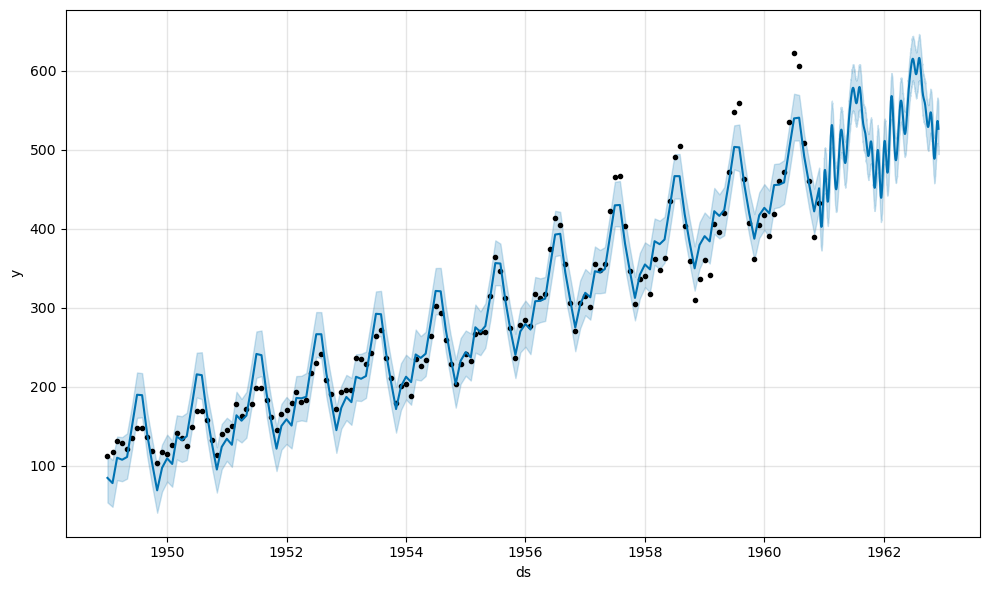

In [18]:
model.plot(prediction)
plt.savefig('prediction.png', bbox_inches='tight')
plt.show();

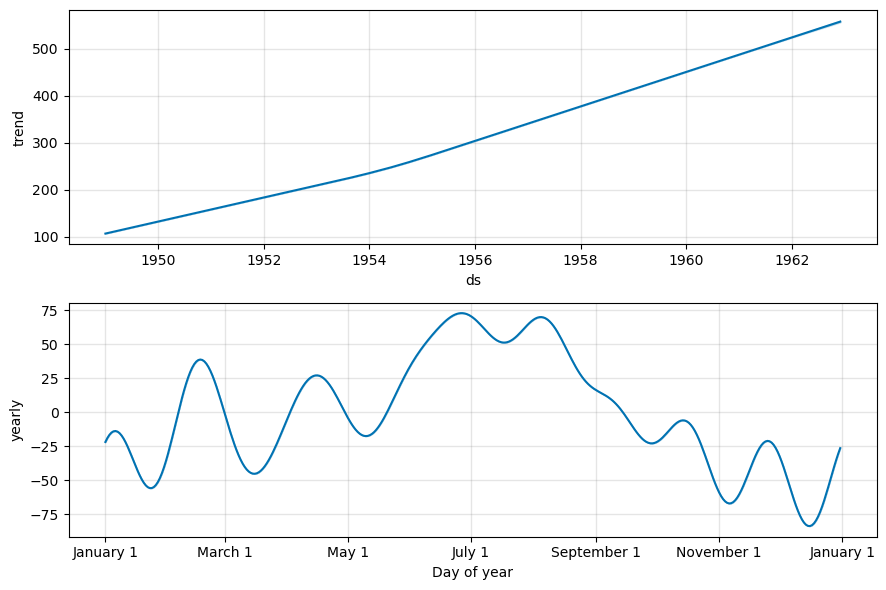

In [24]:
model.plot_components(prediction)
plt.savefig('trend_decomposition.png', bbox_inches='tight')
plt.show();

In [20]:
# initial = '730 days' : first 3 years of data used for training
# period = '180 days' : after every 180 days the model creates a new cutoff, retraining the model from start to that cutoff
# horizon = '365 days' : at each cutoff the model will pforecast the next 365 days and compare with actual values
data_cv = cross_validation(model, initial = '730 days', period = '180 days', horizon = '365 days')
data_cv.head()

  0%|          | 0/19 [00:00<?, ?it/s]

19:16:27 - cmdstanpy - INFO - Chain [1] start processing
19:16:42 - cmdstanpy - INFO - Chain [1] done processing
19:16:43 - cmdstanpy - INFO - Chain [1] start processing
19:16:43 - cmdstanpy - INFO - Chain [1] done processing
19:16:43 - cmdstanpy - INFO - Chain [1] start processing
19:16:43 - cmdstanpy - INFO - Chain [1] done processing
19:16:44 - cmdstanpy - INFO - Chain [1] start processing
19:16:44 - cmdstanpy - INFO - Chain [1] done processing
19:16:44 - cmdstanpy - INFO - Chain [1] start processing
19:16:44 - cmdstanpy - INFO - Chain [1] done processing
19:16:45 - cmdstanpy - INFO - Chain [1] start processing
19:16:45 - cmdstanpy - INFO - Chain [1] done processing
19:16:45 - cmdstanpy - INFO - Chain [1] start processing
19:16:45 - cmdstanpy - INFO - Chain [1] done processing
19:16:45 - cmdstanpy - INFO - Chain [1] start processing
19:16:46 - cmdstanpy - INFO - Chain [1] done processing
19:16:46 - cmdstanpy - INFO - Chain [1] start processing
19:16:46 - cmdstanpy - INFO - Chain [1]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1951-02-01,157.205061,156.977806,157.437731,150,1951-01-18
1,1951-03-01,169.726695,169.037925,170.476990,178,1951-01-18
2,1951-04-01,157.272915,155.884612,158.682402,163,1951-01-18
3,1951-05-01,143.304512,141.162202,145.600385,172,1951-01-18
4,1951-06-01,178.017955,174.926670,181.370568,178,1951-01-18


In [21]:
data_p = performance_metrics(data_cv)
data_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,40 days,1087.585276,32.978558,25.828241,0.078205,0.073741,0.079259,0.227273
1,42 days,1014.336159,31.848645,25.247395,0.076910,0.073741,0.077630,0.181818
2,46 days,909.313866,30.154832,24.670936,0.078810,0.079315,0.078584,0.136364
3,47 days,1044.683167,32.321559,26.845514,0.081984,0.085520,0.082145,0.136364
4,48 days,1034.252775,32.159801,26.300152,0.080102,0.085520,0.080328,0.181818


In [22]:
rmse_value = data_p['rmse'].mean()
rmse_value

26.891590341847735

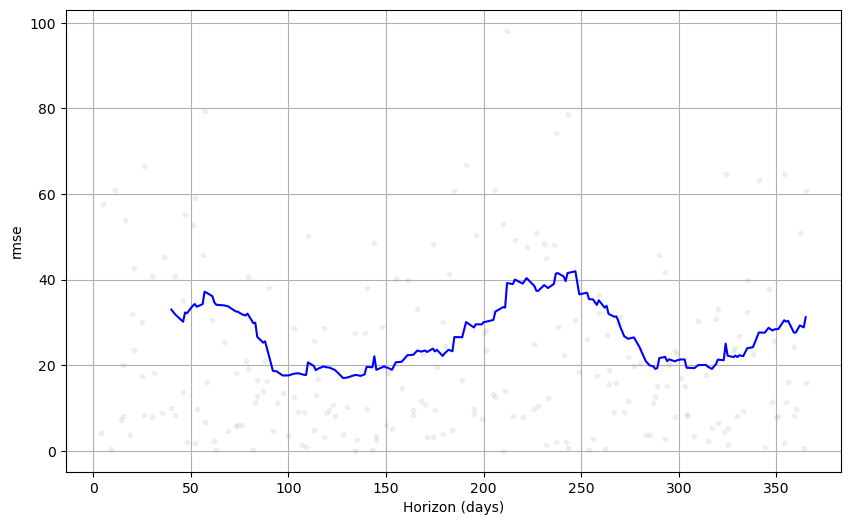

In [25]:
plot_cross_validation_metric(data_cv, metric='rmse')
plt.savefig('rmse_plot.png', bbox_inches='tight')
plt.show();